# Higher-order rules: what the longer rules add

## Imports

In [1]:
import ast
import os
import sys
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sys.path[:0] = [os.path.abspath(".."), os.path.abspath("../..")]

import data_helper as dh
import vis_helper as vh
import complex_vis as cv
from data_helper import base_items, check_rule_overlap, clean_items

## Parameters

In [2]:
RULE_MAX_ITEMS = 3
KINDS = ["attracts", "avoids"]
NO_SELF = True
MAX_FDR = 0.05

# The stage column is chosen per run, not per notebook:
#   SCORE_COLUMN="Pathological score" jupyter nbconvert --execute ...
SCORE_COLUMN = os.environ.get("SCORE_COLUMN", "Clinical score")
SCORE_TAG = "path" if SCORE_COLUMN.startswith("Patho") else "clin"
STAGE_ORDER = ["Control", "Mild", "Severe"]
ORGAN_ORDER = ["Colon", "Duodenum"]

SHAPE_ORDER = ["ant-complex", "con-complex"]
SHAPE_LABELS = {
    "pairwise": "A -> B",
    "ant-complex": "A + B -> C",
    "con-complex": "A -> B + C",
}
CLASS_ORDER = [
    "redundant_by_simpler", "consequent_driven", "simpler_are_noise",
    "consequent_is_noise", "stronger_effect", "new",
]
CLASS_LABELS = {
    "redundant_by_simpler": "a shorter rule said it",
    "consequent_driven": "consequents do it alone",
    "simpler_are_noise": "shorter rules too weak",
    "consequent_is_noise": "backing pair too weak",
    "stronger_effect": "clearly stronger",
    "new": "nothing shorter mined",
}
GROUP_ORDER = {
    SCORE_COLUMN: STAGE_ORDER,
    "Clinical score": STAGE_ORDER,
    "Organ": ORGAN_ORDER,
    "Kind": ["attracts", "avoids"],
}

METRIC = "Lift"
NEW_MIN_STRENGTH = 1.3
MIN_FOVS = 5
TOP_N = 15
FOV_EXAMPLES_PER_CLASS = 1
NEW_FOV_EXAMPLES = 4
MINING_BAR = {
    ("attracts", "Lift"): 1.2,
    ("avoids", "Lift"): 1.25,
    ("attracts", "Conviction"): 1.3,
}


## Data loading

In [3]:
# Only the first run of a rebuild empties the folder, so a second run under a
# different SCORE_COLUMN adds to it instead of replacing it.
if os.environ.get("CLEAR_FIGURES", "1") == "1":
    cv.clear_all_exports()

df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(
    rule_max_items=RULE_MAX_ITEMS,
    kind=None,
    max_fdr=1.0,
    informative_only=False,
)

Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.


Kept 1190114 rules at FDR <= 1.0.


Kept 1172931 rules naming no Unidentified.


Kept 213816 rules (max_items=3, kind=None).


## Short analysis functions

In [4]:
def drop_self_rules(rules):
    if not NO_SELF:
        return rules
    repeated = [
        check_rule_overlap(base_items(a), base_items(c))
        for a, c in zip(rules["Antecedents"], rules["Consequents"])
    ]
    return rules[~pd.Series(repeated, index=rules.index)]


def attach_metadata(rules):
    rules = rules[rules["FOV"].isin(df_fovs["FOV"])]
    wanted = ["Organ", "Biopsy", "PatientID", SCORE_COLUMN]
    columns = ["FOV"] + [name for name in wanted if name not in rules]
    return rules.merge(df_fovs[columns], on="FOV", how="left")


def rule_counts(rules):
    rules = drop_self_rules(rules)
    shape = rules["Rule_Type"].map(SHAPE_LABELS)
    return pd.DataFrame({
        "rules": shape.value_counts(),
        "significant": shape[rules["Individual_FDR"] <= MAX_FDR].value_counts(),
    }).reindex([SHAPE_LABELS[s] for s in ["pairwise"] + SHAPE_ORDER])

In [5]:
def row_order(rules, split_by):
    if not split_by:
        return SHAPE_ORDER
    present = list(rules[split_by].dropna().unique())
    groups = [value for value in GROUP_ORDER.get(split_by, []) if value in present]
    groups += [value for value in present if value not in groups]
    return [(group, shape) for group in groups for shape in SHAPE_ORDER]


def class_split(rules, split_by=None, max_fdr=None):
    rules = drop_self_rules(rules)
    rules = rules[rules["Rule_Type"].isin(SHAPE_ORDER)]
    if max_fdr is not None:
        rules = rules[rules["Individual_FDR"] <= max_fdr]
    keys = ([split_by] if split_by else []) + ["Rule_Type"]
    counts = rules.groupby(keys + ["Complex_Class"]).size().unstack(fill_value=0)
    counts = counts[[name for name in CLASS_ORDER if name in counts]]
    order = row_order(rules, split_by)
    return counts.reindex([row for row in order if row in counts.index])


def show_class_split(rules, kind, split_by=None, max_fdr=None, organ=None, save=None):
    subtitle = f"Split by {split_by.lower()}" if split_by else (
        "Statistically supported rules" if max_fdr is not None else "All mined rules"
    )
    fdr = f"FDR ≤ {max_fdr}" if max_fdr is not None else "all FDR values"
    cv.plot_class_split(
        class_split(rules, split_by, max_fdr), labels=SHAPE_LABELS,
        class_labels=CLASS_LABELS, organ=organ, subtitle=subtitle,
        params=f"{kind} · {fdr}", save=save,
    )


In [6]:
def strength(rules, metric=METRIC):
    value = rules[metric].astype(float)
    if metric == "Leverage":
        return value.abs()
    return value.where(rules["Kind"] == "attracts", 1 / value.clip(lower=1e-6))


def rule_key(rules):
    ant = rules["Antecedents"].map(lambda value: " + ".join(sorted(ast.literal_eval(value))))
    con = rules["Consequents"].map(lambda value: " + ".join(sorted(ast.literal_eval(value))))
    return ant + " -> " + con


def plain_name(name):
    if not isinstance(name, str):
        return "nothing shorter was mined"
    sides = [
        ", ".join(sorted(item.replace("_CENTER", "").replace("_NEIGHBOR", "")
                         for item in side.split(" + ")))
        for side in name.split(" -> ")
    ]
    return " -> ".join(sides)


def best_parent(rules, metric=METRIC):
    keys = zip(rules["FOV"], rules["Kind"], rule_key(rules))
    found = {key: values for key, values in zip(keys, zip(
        strength(rules, metric), rules["Individual_FDR"], rules["Lift"],
        rules["Confidence"], rules["Leverage"], rules["Support"],
        rules["Conviction"],
    ))}
    details = []
    for fov, kind, simpler in zip(rules["FOV"], rules["Kind"], rules["Simpler_Rules"]):
        parents = [(*found[(fov, kind, name)], name) for name in ast.literal_eval(simpler)
                   if (fov, kind, name) in found]
        if not parents:
            details.append({"parent": np.nan, "parent_name": plain_name(None)})
            continue
        value, fdr, lift, confidence, leverage, support, conviction, name = max(
            parents, key=lambda item: item[0],
        )
        details.append({
            "parent": value, "parent_name": plain_name(name),
            "parent_rule": name, "parent_fdr": fdr,
            "parent_Lift": lift, "parent_Confidence": confidence,
            "parent_Leverage": leverage, "parent_Support": support,
            "parent_Conviction": conviction,
        })
    return pd.DataFrame(details, index=rules.index)

In [7]:
def gain_table(rules, per="rule"):
    rules = drop_self_rules(rules)
    longer = rules[rules["Rule_Type"].isin(SHAPE_ORDER)].copy()
    longer["strength"] = strength(longer)
    parent_columns = ["parent", "parent_name", "parent_rule", "parent_fdr",
                      "parent_Lift", "parent_Confidence", "parent_Leverage",
                      "parent_Support", "parent_Conviction"]
    longer[parent_columns] = best_parent(rules).reindex(longer.index)[parent_columns]
    kind = rules["Kind"].iat[0]
    longer["parent"] = longer["parent"].fillna(MINING_BAR.get((kind, METRIC), 1.0))

    kept = longer[
        longer["Adds_Information"] & (longer["Individual_FDR"] <= MAX_FDR)
    ].copy()
    kept["name"] = (kept["Antecedents"].map(clean_items) + " -> "
                    + kept["Consequents"].map(clean_items))
    kept["gain"] = kept["strength"] / kept["parent"]
    support = kept.groupby("name")["FOV"].nunique()
    kept = kept[kept["name"].isin(support[support >= MIN_FOVS].index)]

    if per == "fov":
        return kept.rename(columns={"Complex_Class": "verdict"}).sort_values(
            "gain", ascending=False)

    table = kept.groupby(["name", "Rule_Type", "Complex_Class"]).agg(
        strength=("strength", "median"), parent=("parent", "median"),
        fovs=("FOV", "nunique"),
        parent_name=("parent_name", lambda values: values.mode().iat[0]),
    ).reset_index().rename(columns={"Complex_Class": "verdict"})
    table["gain"] = table["strength"] / table["parent"]
    return table[table["fovs"] >= MIN_FOVS].sort_values("gain", ascending=False)


def plot_params(kind, extra=None):
    values = [kind, f"FDR ≤ {MAX_FDR}", f"{MIN_FOVS}+ FOVs", extra]
    return " · ".join(value for value in values if value)


def metric_label(kind):
    return "Inverse lift" if kind == "avoids" and METRIC == "Lift" else METRIC


def show_gain_dumbbell(table, kind, include_new=False, organ=None, save=None):
    if not include_new:
        table = table[table["verdict"] != "new"]
    parent = "measured and lower-bound gains" if include_new else "measured gains only"
    cv.plot_gain_dumbbell(
        table, class_labels=CLASS_LABELS, metric=metric_label(kind), top_n=TOP_N,
        organ=organ, subtitle=f"Top {TOP_N} rules by gain",
        params=plot_params(kind, parent), save=save,
    )


In [8]:
def choose_fov_examples(summary, rows):
    measured = rows[rows["parent_rule"].notna()].copy()
    stronger = measured[measured["verdict"] == "stronger_effect"].head(1)

    significance = measured[measured["Individual_FDR"] < measured["parent_fdr"]].copy()
    significance["crosses_fdr"] = significance["parent_fdr"] > MAX_FDR
    significance["fdr_gain"] = ((significance["parent_fdr"] + 1e-12)
                                  / (significance["Individual_FDR"] + 1e-12))
    significance = significance.sort_values(
        ["crosses_fdr", "fdr_gain"], ascending=False,
    )
    if not stronger.empty:
        significance = significance[significance.index != stronger.index[0]]
    significance = significance.head(1)
    chosen = [("Stronger than its best simpler rule", stronger),
              ("More statistically significant than its best simpler rule", significance)]

    examples = []
    for reason, block in chosen:
        if block.empty:
            continue
        row = block.iloc[0]
        examples.append({
            "reason": reason,
            "FOV": row["FOV"], "rule": row["name"],
            "antecedent_cells": base_items(row["Antecedents"]),
            "consequent_cells": base_items(row["Consequents"]),
            "simpler_rules": [row["parent_rule"]],
            "complex_metrics": {name: row.get(name, np.nan) for name in
                                ["Lift", "Confidence", "Leverage", "Support",
                                 "Conviction", "Individual_FDR"]},
            "simpler_metrics": [{
                "Lift": row["parent_Lift"],
                "Confidence": row["parent_Confidence"],
                "Leverage": row["parent_Leverage"],
                "Support": row["parent_Support"],
                "Conviction": row["parent_Conviction"],
                "Individual_FDR": row["parent_fdr"],
            }],
            "detail": (f"{reason} · {METRIC.lower()} gain {row['gain']:.1f}x · "
                       f"complex FDR {row['Individual_FDR']:.3g}"),
        })
    return pd.DataFrame(examples)


def slug(text):
    """A short file-safe name for a rule, a reason or an organ."""
    text = str(text).lower().replace(" -> ", "_").replace(",", "").replace(" ", "_")
    return "".join(ch for ch in text if ch.isalnum() or ch == "_")[:60]


REASON_SLUG = {
    "Stronger than its best simpler rule": "stronger",
    "More statistically significant than its best simpler rule": "significance",
}


def show_fov_examples(summary, rows, prefix):
    """Draw both FOV proofs and save each under a predictable name."""
    examples = choose_fov_examples(summary, rows)
    if examples.empty:
        print("No measured-parent FOV examples.")
        return
    display(examples[["FOV", "rule", "detail"]])
    for _, example in examples.iterrows():
        reason = REASON_SLUG.get(example["reason"], slug(example["reason"]))
        vh.plot_rule_fov_pairs(
            [example], df_cells, df_fovs, save=f"{prefix}_fov_{reason}.png",
        )


def new_results(rules):
    """New rules that recur, ranked by how many FOVs carry them.

    Recurrence is counted before the strength gate, so a rule seen in many FOVs is
    never dropped for sitting just under NEW_MIN_STRENGTH, and the gate is applied to
    a rule's median strength rather than to each occurrence. How many recurrent rules
    the gate removes is printed, so the cost of the threshold stays visible.
    """
    rows = gain_table(rules, per="fov")
    rows = rows[rows["verdict"] == "new"].copy()

    fovs_per_rule = rows.groupby("name")["FOV"].nunique()
    recurrent = fovs_per_rule[fovs_per_rule >= MIN_FOVS].index
    rows = rows[rows["name"].isin(recurrent)]
    if rows.empty:
        return pd.DataFrame(), rows

    median_strength = rows.groupby("name")["strength"].median()
    strong = median_strength[median_strength >= NEW_MIN_STRENGTH].index
    print(f"{len(recurrent)} new rules in {MIN_FOVS}+ FOVs; "
          f"{len(recurrent) - len(strong)} dropped by median strength "
          f"< {NEW_MIN_STRENGTH}")
    rows = rows[rows["name"].isin(strong)]
    if rows.empty:
        return pd.DataFrame(), rows

    table = rows.groupby(["name", "Rule_Type", "verdict"]).agg(
        strength=("strength", "median"), parent=("parent", "median"),
        fovs=("FOV", "nunique"),
        parent_name=("parent_name", lambda values: values.mode().iat[0]),
    ).reset_index()
    table["gain"] = table["strength"] / table["parent"]
    return table.sort_values(["fovs", "strength"], ascending=False), rows


def show_new_fov_examples(summary, rows, prefix, n=FOV_EXAMPLES_PER_CLASS):
    names = list(summary.head(n)["name"])
    examples = []
    for name in names:
        current = rows[rows["name"] == name]
        middle = current["strength"].median()
        row = current.loc[(current["strength"] - middle).abs().idxmin()]
        examples.append({
            "FOV": row["FOV"], "rule": row["name"],
            "antecedent_cells": base_items(row["Antecedents"]),
            "consequent_cells": base_items(row["Consequents"]),
            "simpler_rules": [],
            "complex_metrics": {key: row.get(key, np.nan) for key in
                                ["Lift", "Confidence", "Leverage", "Support",
                                 "Conviction"]},
            "detail": (f"New rule · effect strength ≥ {NEW_MIN_STRENGTH} · "
                       f"FDR {row['Individual_FDR']:.3g}"),
        })
    examples = pd.DataFrame(examples)
    if not examples.empty:
        display(examples[["FOV", "rule", "detail"]])
        for _, example in examples.iterrows():
            vh.plot_rule_fov_pairs(
                [example], df_cells, df_fovs,
                save=f"{prefix}_newfov_{slug(example['rule'])}.png",
            )


## Results

## Attractions

### Rule counts

In [9]:
df_results = attach_metadata(df_results)
for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    display(rule_counts(df_results[df_results["Kind"] == kind]))

#### Attracts

,rules,significant
Rule_Type,,
A -> B,4955,2745
A + B -> C,55484,24482
A -> B + C,10763,4756


### Verdicts

#### Attracts

Complex_Class,redundant_by_simpler,consequent_driven,simpler_are_noise,consequent_is_noise,stronger_effect,new
Rule_Type,,,,,,
ant-complex,20763,0,12732,0,5684,16305
con-complex,3467,362,3087,202,2441,1204


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_attracts_all.png


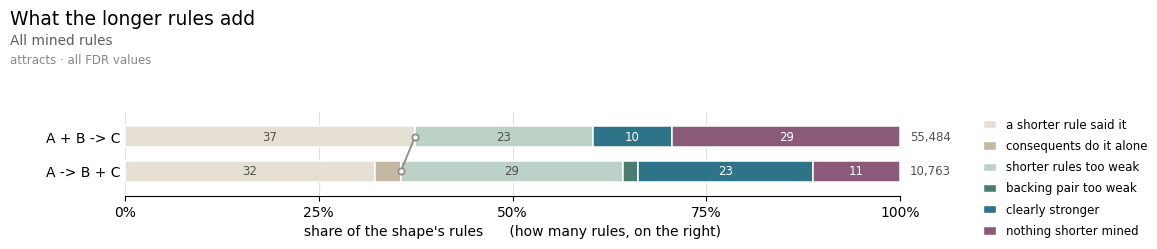

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_attracts_supported.png


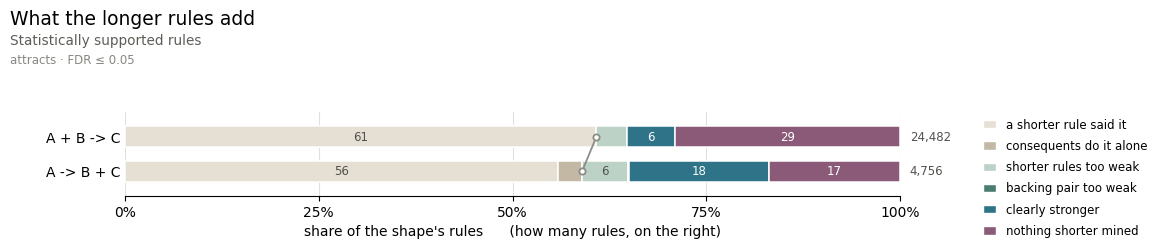

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_attracts_by_stage_path.png


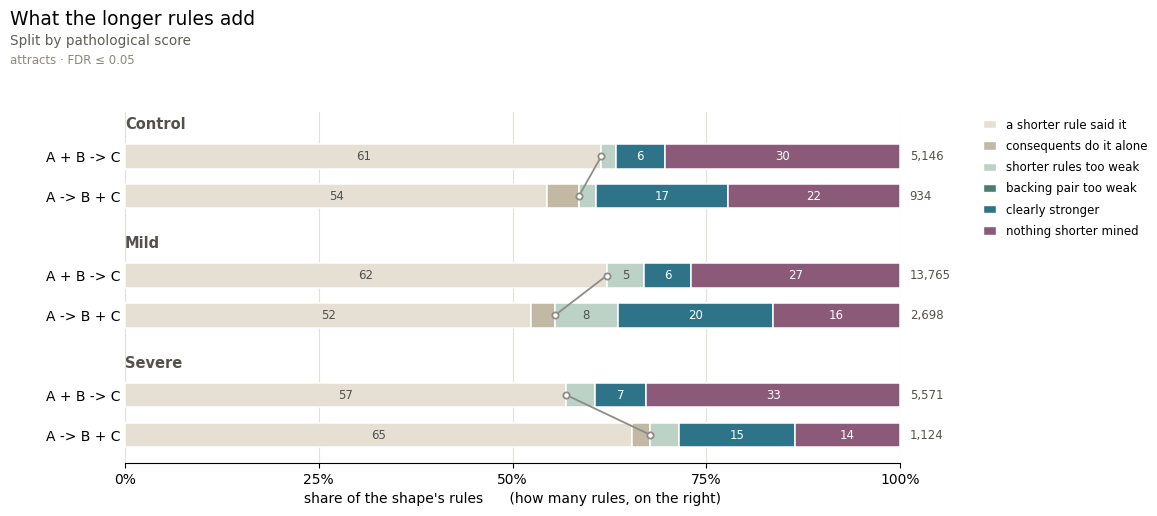

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_attracts_colon.png


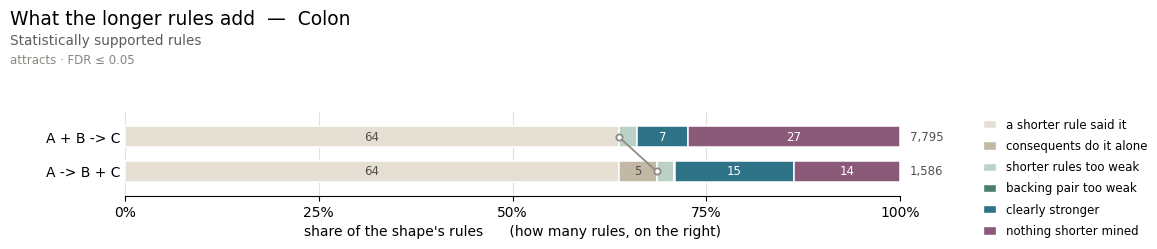

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_attracts_duodenum.png


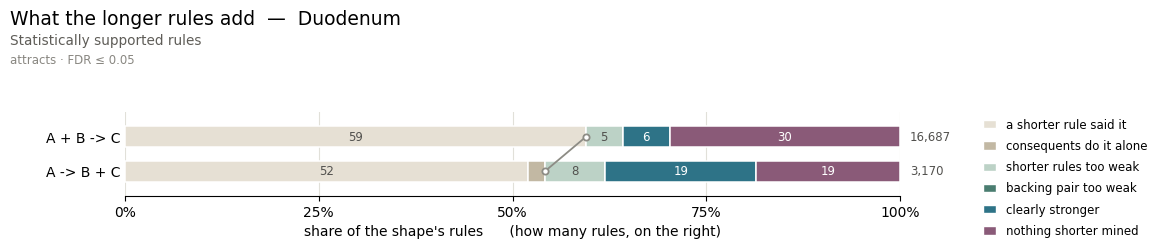

In [10]:
for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    rules = df_results[df_results["Kind"] == kind]
    display(class_split(rules))
    show_class_split(rules, kind, save=f"verdicts_{kind}_all.png")
    show_class_split(rules, kind, max_fdr=MAX_FDR,
                     save=f"verdicts_{kind}_supported.png")
    show_class_split(rules, kind, split_by=SCORE_COLUMN, max_fdr=MAX_FDR,
                     save=f"verdicts_{kind}_by_stage_{SCORE_TAG}.png")
    for organ in ORGAN_ORDER:
        show_class_split(
            rules[rules["Organ"] == organ], kind, max_fdr=MAX_FDR, organ=organ,
            save=f"verdicts_{kind}_{organ.lower()}.png",
        )


### Strength gains

#### Attracts

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
608,"Epithelial, Muscle -> Paneth",ant-complex,new,4.850917,1.2,5,nothing shorter was mined,4.042431
346,"Endocrine, Epithelial -> Paneth",ant-complex,new,3.895374,1.2,6,nothing shorter was mined,3.246145
600,"Epithelial, Muscle -> Endocrine",ant-complex,new,3.454289,1.2,5,nothing shorter was mined,2.878574
612,"Epithelial, Neuroendocrine -> Endocrine",ant-complex,new,3.437963,1.2,5,nothing shorter was mined,2.864969
1150,"Muscle, SMV -> Endothelial",ant-complex,new,3.230002,1.2,9,nothing shorter was mined,2.691668
658,"Epithelial, Paneth -> Endocrine",ant-complex,new,3.159119,1.2,10,nothing shorter was mined,2.632599
1215,"Neuron, SMV -> Mesenchymal_VIM",ant-complex,new,3.128678,1.2,5,nothing shorter was mined,2.607231
858,"Fibroblast, Plasma -> Plasma_CD38",ant-complex,new,3.039208,1.2,6,nothing shorter was mined,2.532674
942,"ImmuneOther, SMV -> Muscle",ant-complex,new,2.993085,1.2,5,nothing shorter was mined,2.494238
199,"CD4T, SMV -> Endothelial",ant-complex,new,2.985738,1.2,6,nothing shorter was mined,2.488115


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\gain_attracts_measured.png


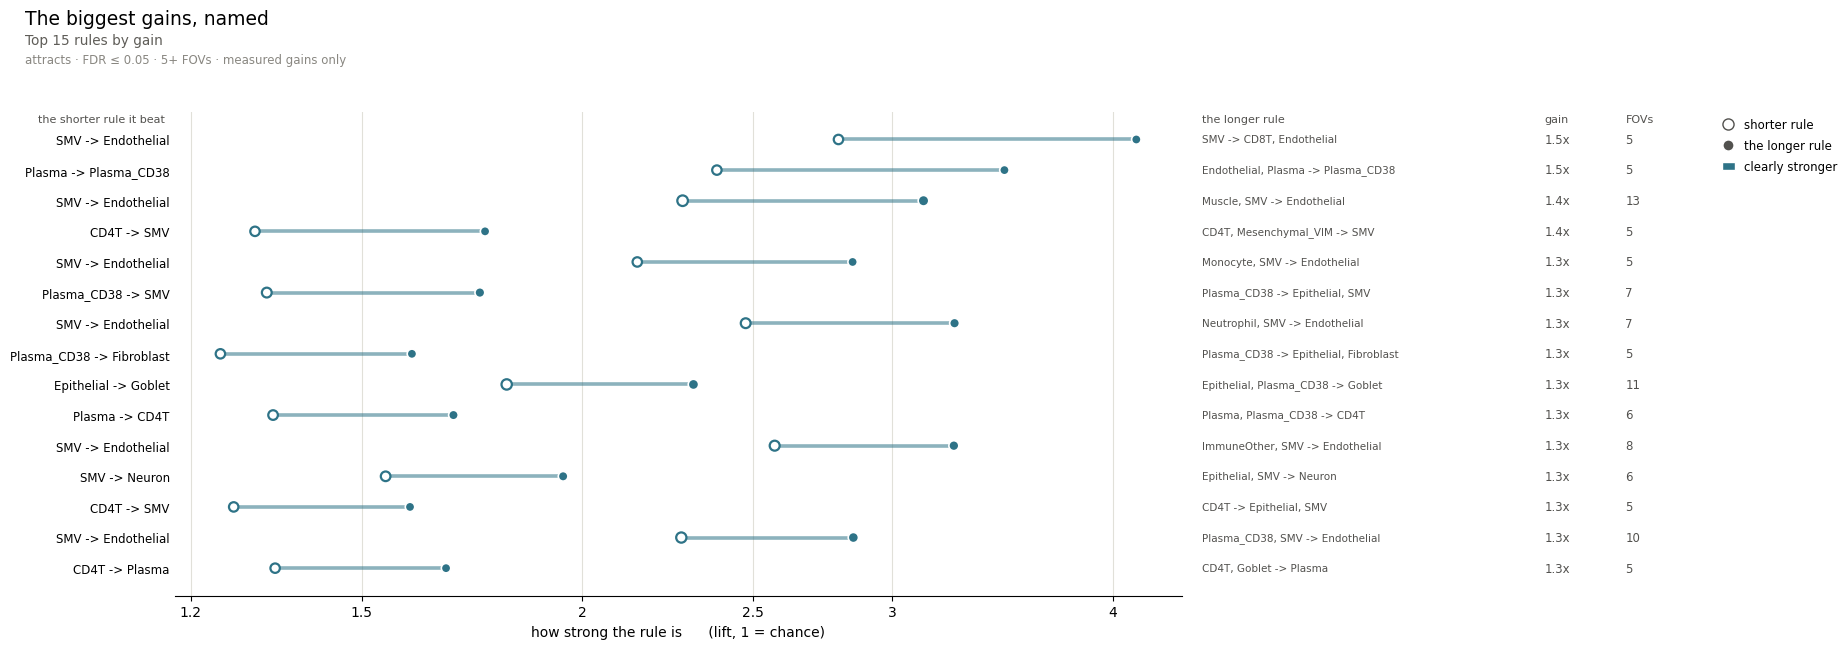

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\gain_attracts_with_new.png


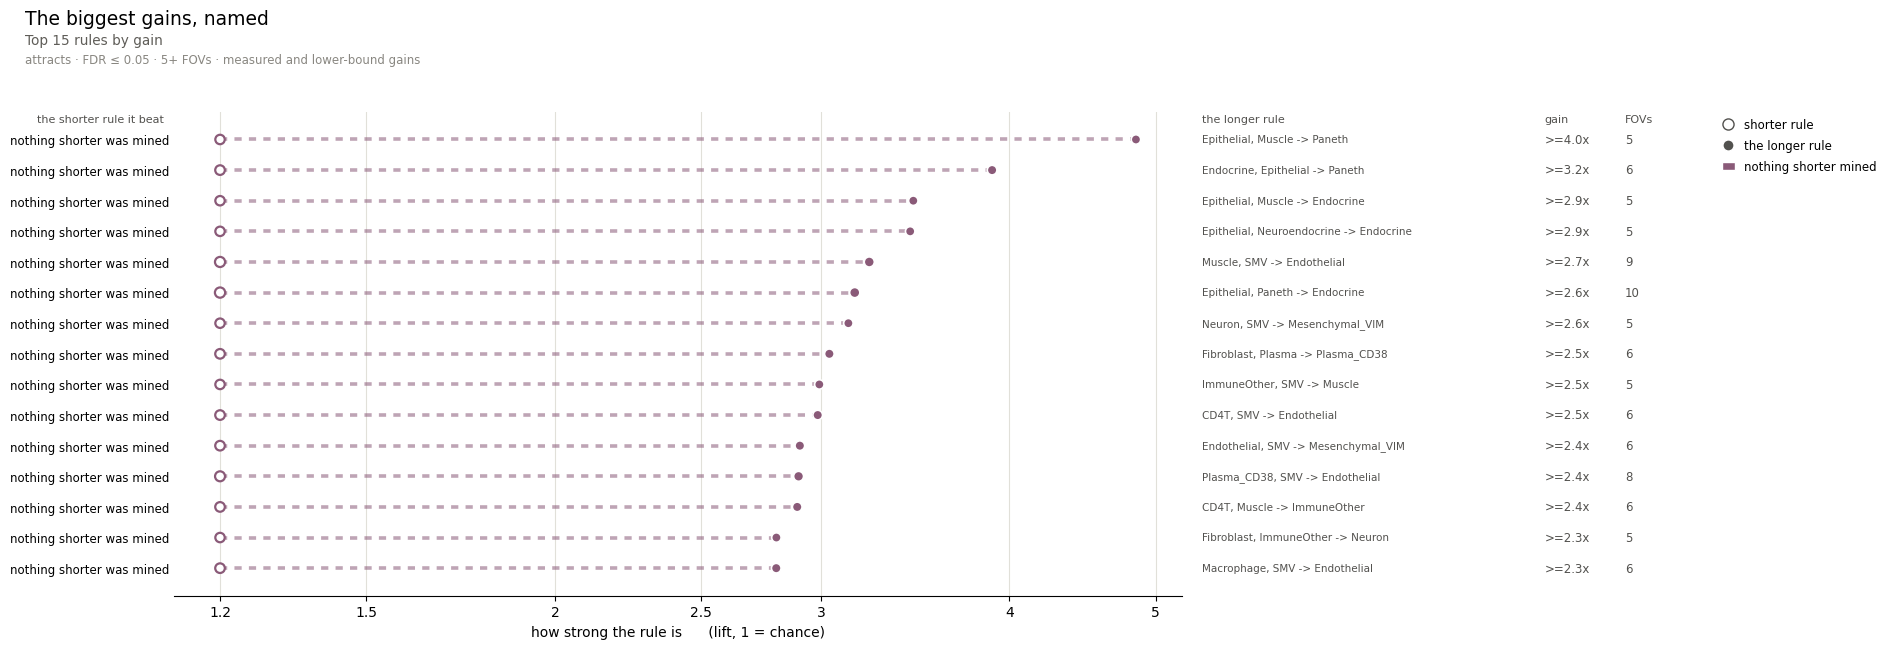

,FOV,rule,detail
0,GVHD_38_FOV_2,"Epithelial, Muscle -> Paneth",Stronger than its best simpler rule · lift gai...
1,GVHD_36_FOV_2,"Epithelial, Plasma -> CD4T",More statistically significant than its best s...


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_fov_stronger.png


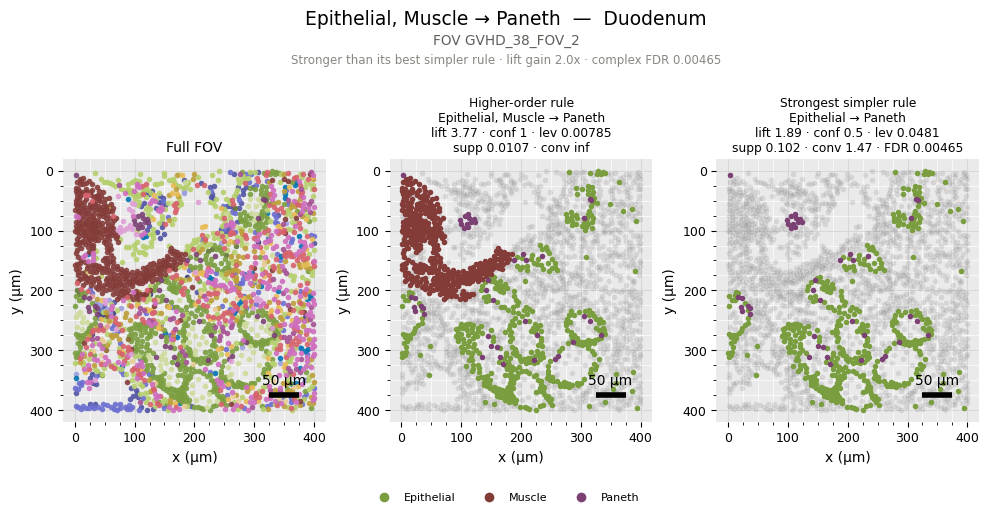

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_fov_significance.png


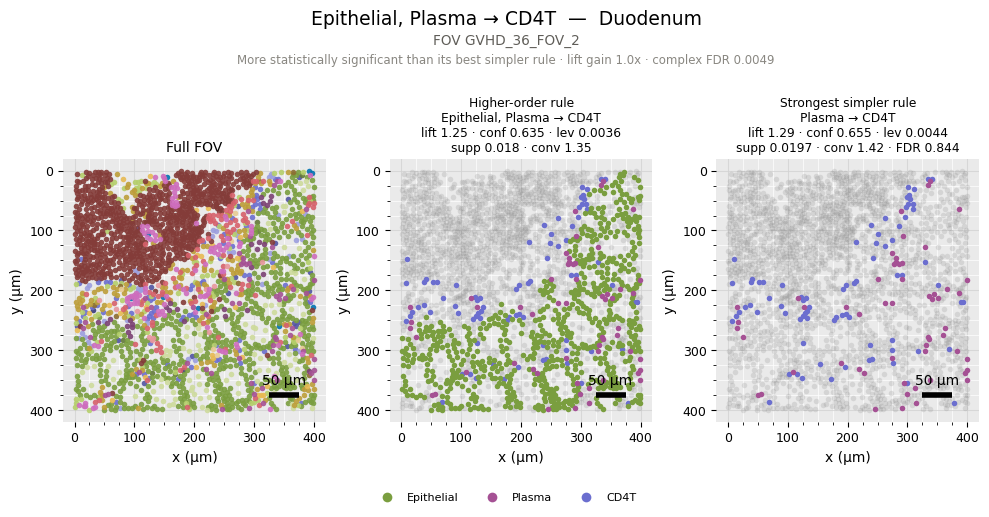

In [11]:
for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    rules = df_results[df_results["Kind"] == kind]
    gains = gain_table(rules)
    gain_rows = gain_table(rules, per="fov")
    display(gains.head(TOP_N))
    show_gain_dumbbell(gains, kind, save=f"gain_{kind}_measured.png")
    show_gain_dumbbell(gains, kind, include_new=True,
                       save=f"gain_{kind}_with_new.png")
    show_fov_examples(gains, gain_rows, prefix=kind)


### New complex rules

#### Attracts

447 new rules in 5+ FOVs; 315 dropped by median strength < 1.3


,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
43,"Epithelial, Fibroblast -> Plasma",ant-complex,new,1.304644,1.2,34,nothing shorter was mined,1.087203
53,"Epithelial, Macrophage -> Plasma",ant-complex,new,1.372049,1.2,33,nothing shorter was mined,1.143374
81,"Epithelial, SMV -> Plasma",ant-complex,new,1.377392,1.2,28,nothing shorter was mined,1.147827
84,"Fibroblast, Goblet -> Plasma",ant-complex,new,1.333355,1.2,20,nothing shorter was mined,1.111129
25,"Endocrine, Fibroblast -> Epithelial",ant-complex,new,1.489952,1.2,18,nothing shorter was mined,1.241627
26,"Endocrine, Macrophage -> Epithelial",ant-complex,new,1.729252,1.2,16,nothing shorter was mined,1.441043
108,"Macrophage, Muscle -> Neuron",ant-complex,new,1.611361,1.2,16,nothing shorter was mined,1.342801
91,"Fibroblast, Muscle -> Neuron",ant-complex,new,1.880258,1.2,15,nothing shorter was mined,1.566881
73,"Epithelial, SMV -> CD4T",ant-complex,new,1.317756,1.2,15,nothing shorter was mined,1.098130
40,"Epithelial, Fibroblast -> CD4T",ant-complex,new,1.307140,1.2,15,nothing shorter was mined,1.089283


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\gain_new_attracts.png


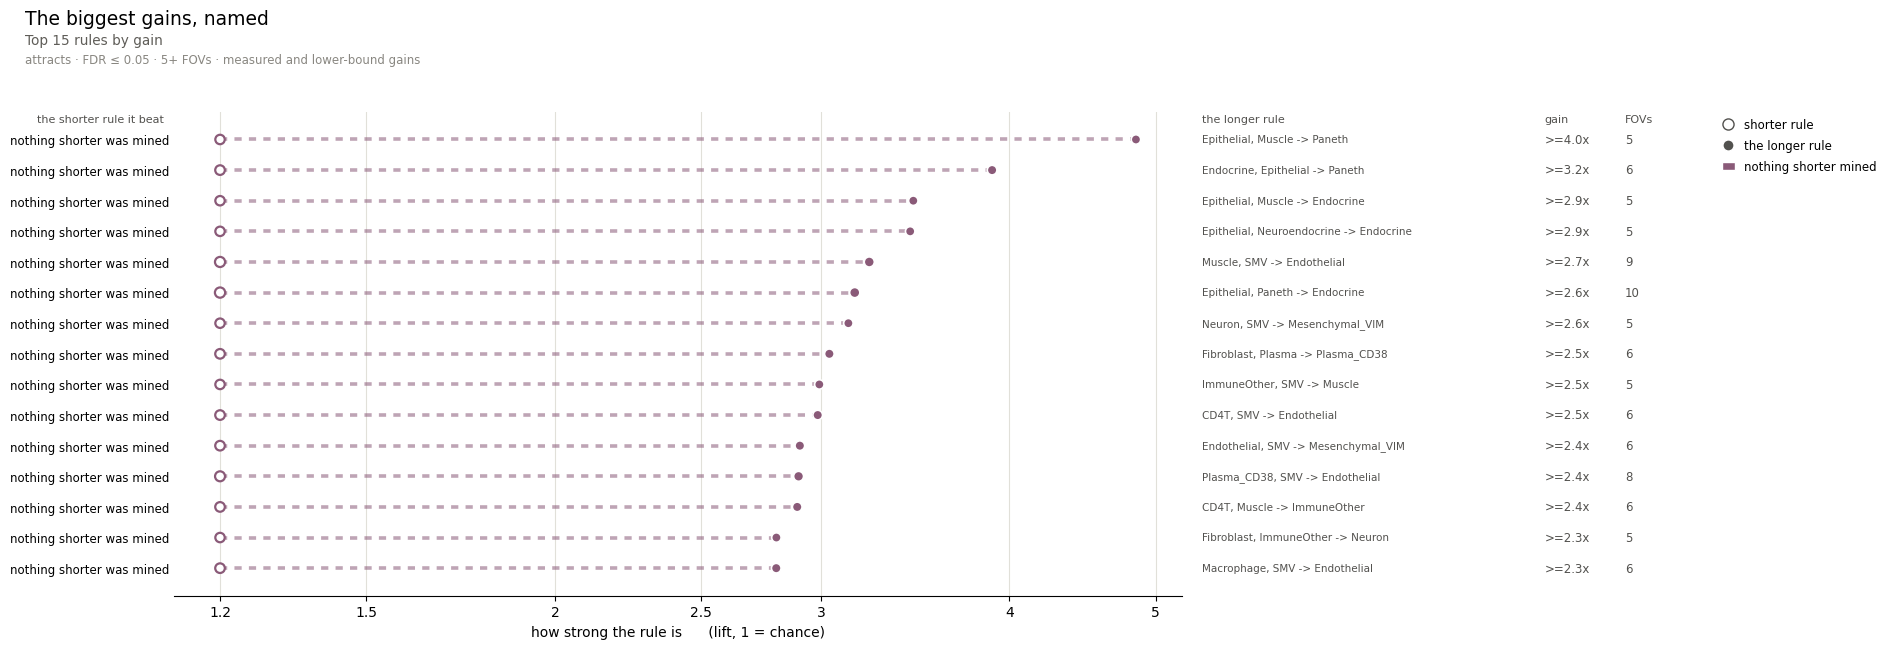

,FOV,rule,detail
0,GVHD_29_FOV_3,"Epithelial, Fibroblast -> Plasma",New rule · effect strength ≥ 1.3 · FDR 0.0454
1,GVHD_54_FOV_4,"Epithelial, Macrophage -> Plasma",New rule · effect strength ≥ 1.3 · FDR 0.00384
2,GVHD_30_FOV_1,"Epithelial, SMV -> Plasma",New rule · effect strength ≥ 1.3 · FDR 0.0135
3,GVHD_12_FOV_5,"Fibroblast, Goblet -> Plasma",New rule · effect strength ≥ 1.3 · FDR 0.0247


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_newfov_epithelial_fibroblast_plasma.png


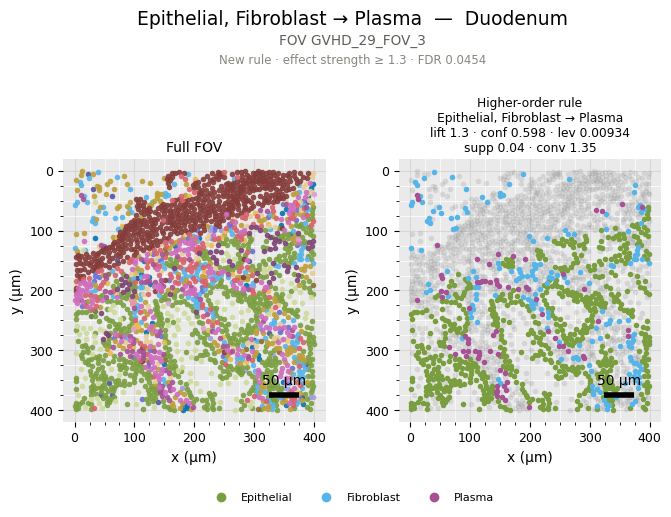

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_newfov_epithelial_macrophage_plasma.png


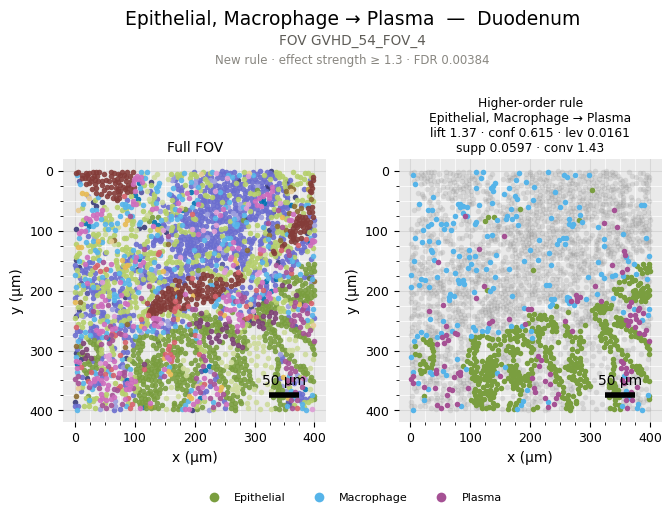

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_newfov_epithelial_smv_plasma.png


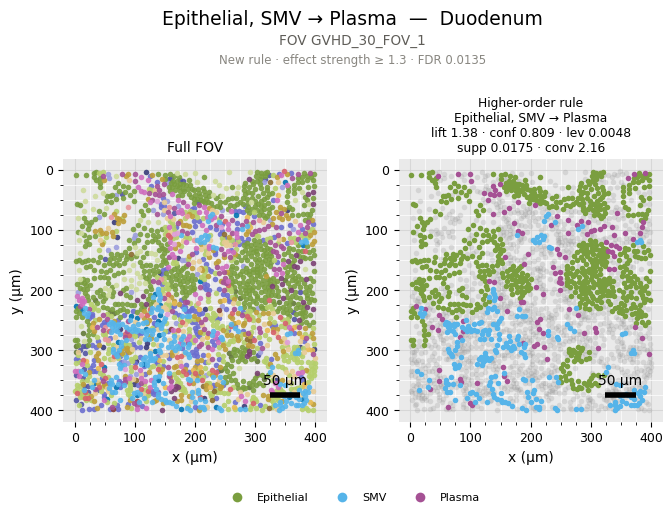

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_newfov_fibroblast_goblet_plasma.png


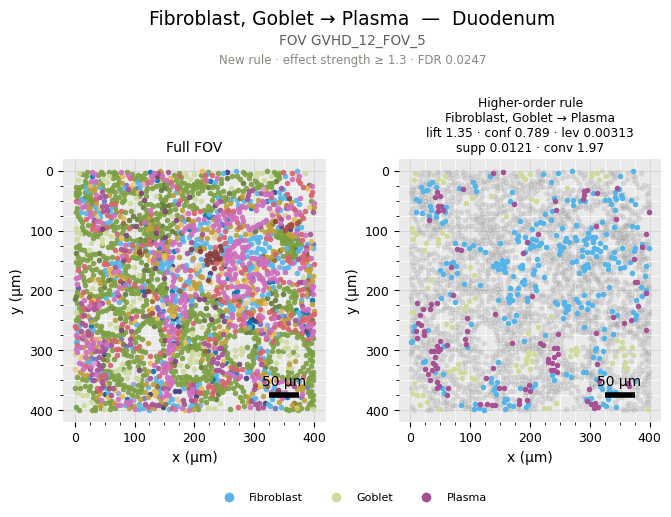

In [12]:
for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    rules = df_results[df_results["Kind"] == kind]
    new_table, new_rows = new_results(rules)
    display(new_table.head(TOP_N))
    show_gain_dumbbell(new_table, kind, include_new=True,
                       save=f"gain_new_{kind}.png")
    show_new_fov_examples(new_table, new_rows, prefix=kind, n=NEW_FOV_EXAMPLES)

### Colon and duodenum

#### Attracts

##### Colon

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
72,"Endothelial, Macrophage -> SMV",ant-complex,new,3.466362,1.200000,6,nothing shorter was mined,2.888635
70,"Endothelial, Fibroblast -> SMV",ant-complex,new,2.984991,1.200000,5,nothing shorter was mined,2.487492
200,"Neuron, SMV -> Endothelial",ant-complex,new,2.801504,1.200000,5,nothing shorter was mined,2.334586
148,"Fibroblast, Muscle -> Neuron",ant-complex,new,2.390655,1.200000,8,nothing shorter was mined,1.992212
224,"SMV -> CD8T, Endothelial",con-complex,stronger_effect,4.124857,2.795846,5,SMV -> Endothelial,1.475352
197,"Muscle, SMV -> Endothelial",ant-complex,stronger_effect,5.206199,3.594438,6,SMV -> Endothelial,1.448404
56,"Endocrine, Macrophage -> Epithelial",ant-complex,new,1.661893,1.200000,7,nothing shorter was mined,1.384911
54,"Endocrine, Fibroblast -> Epithelial",ant-complex,new,1.646727,1.200000,10,nothing shorter was mined,1.372272
117,"Epithelial, SMV -> Endothelial",ant-complex,stronger_effect,3.292535,2.558206,5,SMV -> Endothelial,1.287049
202,"Neuron, SMV -> Endothelial",ant-complex,stronger_effect,3.890452,3.055561,8,SMV -> Endothelial,1.273236


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\gain_attracts_colon_measured.png


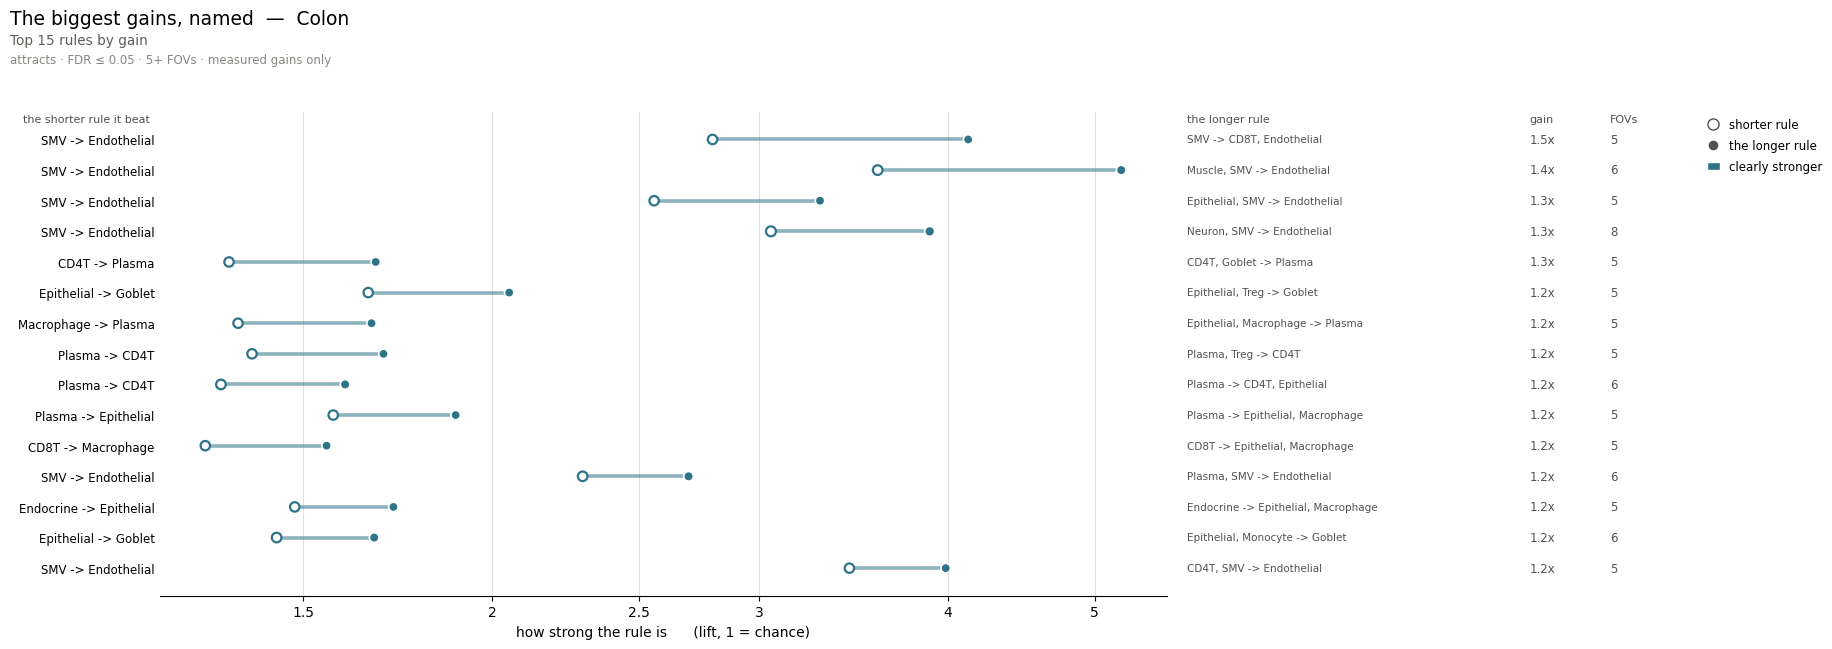

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\gain_attracts_colon_with_new.png


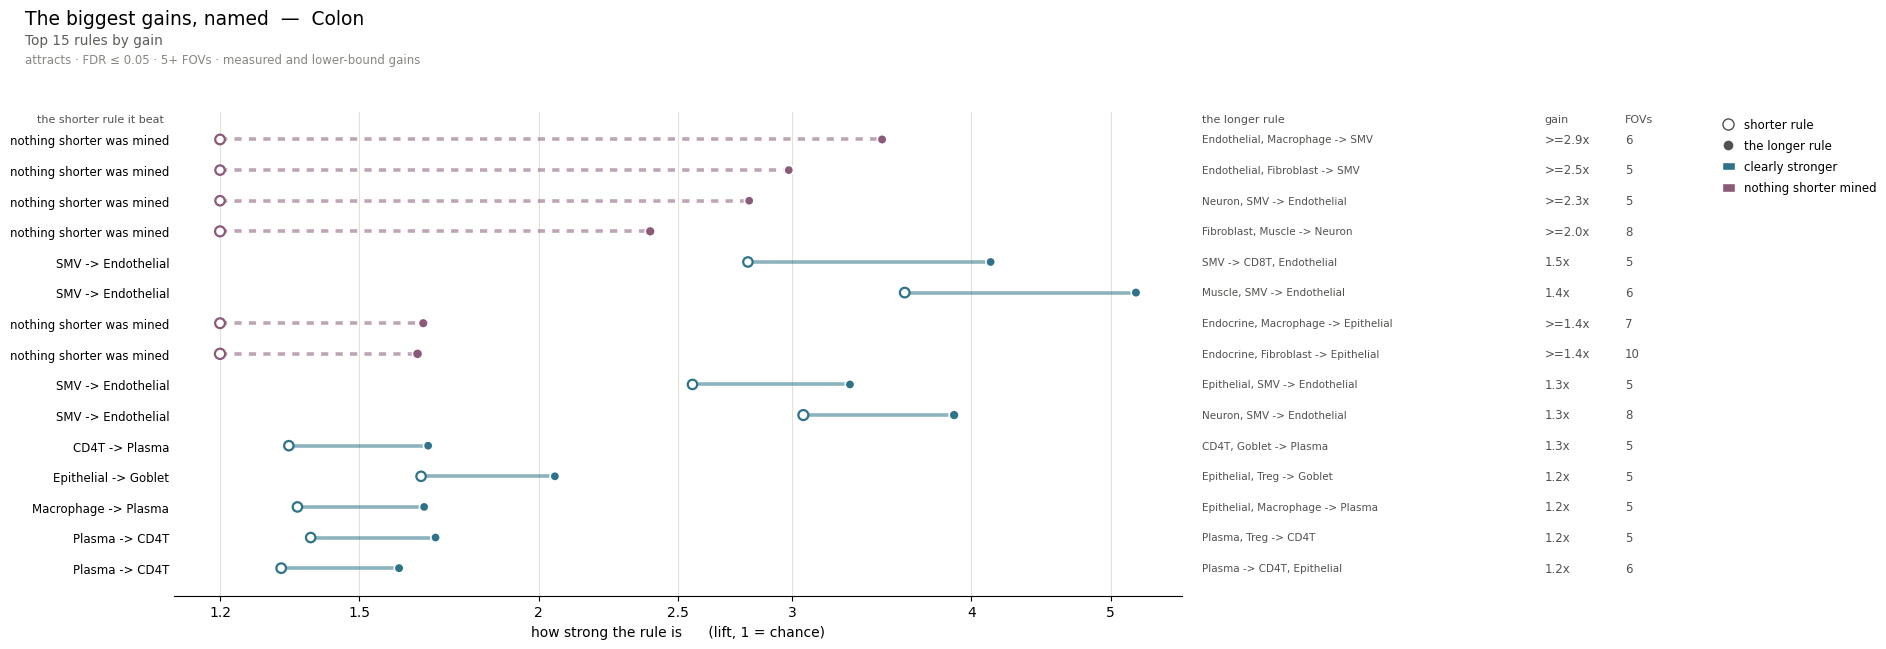

,FOV,rule,detail
0,GVHD_25_FOV_1,"Muscle, SMV -> Endothelial",Stronger than its best simpler rule · lift gai...
1,GVHD_42_FOV_4,"Epithelial, Neuron -> Macrophage",More statistically significant than its best s...


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_colon_fov_stronger.png


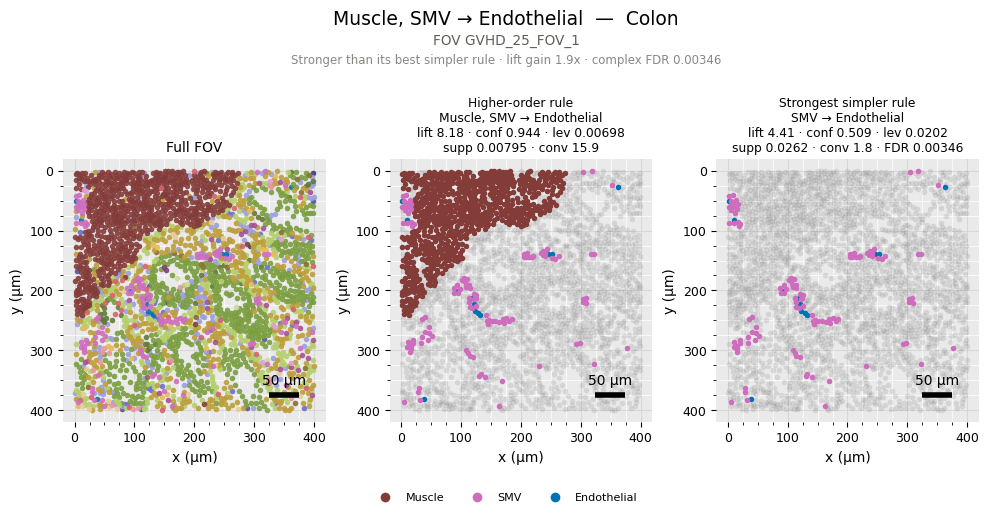

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_colon_fov_significance.png


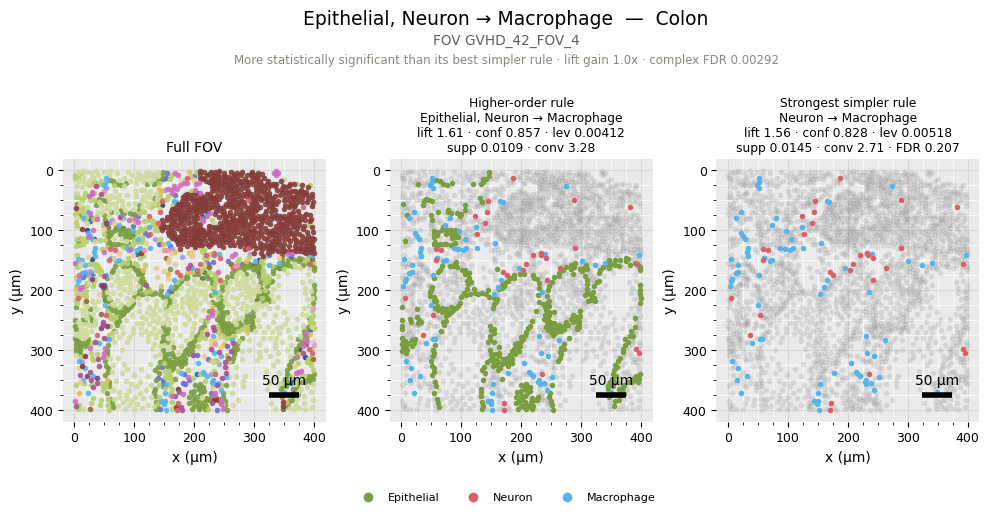

##### Duodenum

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
390,"Epithelial, Muscle -> Paneth",ant-complex,new,4.850917,1.2,5,nothing shorter was mined,4.042431
208,"Endocrine, Epithelial -> Paneth",ant-complex,new,3.895374,1.2,6,nothing shorter was mined,3.246145
394,"Epithelial, Neuroendocrine -> Endocrine",ant-complex,new,3.437963,1.2,5,nothing shorter was mined,2.864969
297,"Endothelial, SMV -> Mesenchymal_VIM",ant-complex,new,3.301761,1.2,5,nothing shorter was mined,2.751467
432,"Epithelial, Paneth -> Endocrine",ant-complex,new,3.159119,1.2,10,nothing shorter was mined,2.632599
745,"Muscle, SMV -> Endothelial",ant-complex,new,3.129256,1.2,8,nothing shorter was mined,2.607714
564,"Fibroblast, Plasma -> Plasma_CD38",ant-complex,new,3.039208,1.2,6,nothing shorter was mined,2.532674
613,"ImmuneOther, SMV -> Muscle",ant-complex,new,2.993085,1.2,5,nothing shorter was mined,2.494238
747,"Muscle, SMV -> ImmuneOther",ant-complex,new,2.732794,1.2,5,nothing shorter was mined,2.277328
482,"Epithelial, SMV -> Endothelial",ant-complex,new,2.657314,1.2,10,nothing shorter was mined,2.214428


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\gain_attracts_duodenum_measured.png


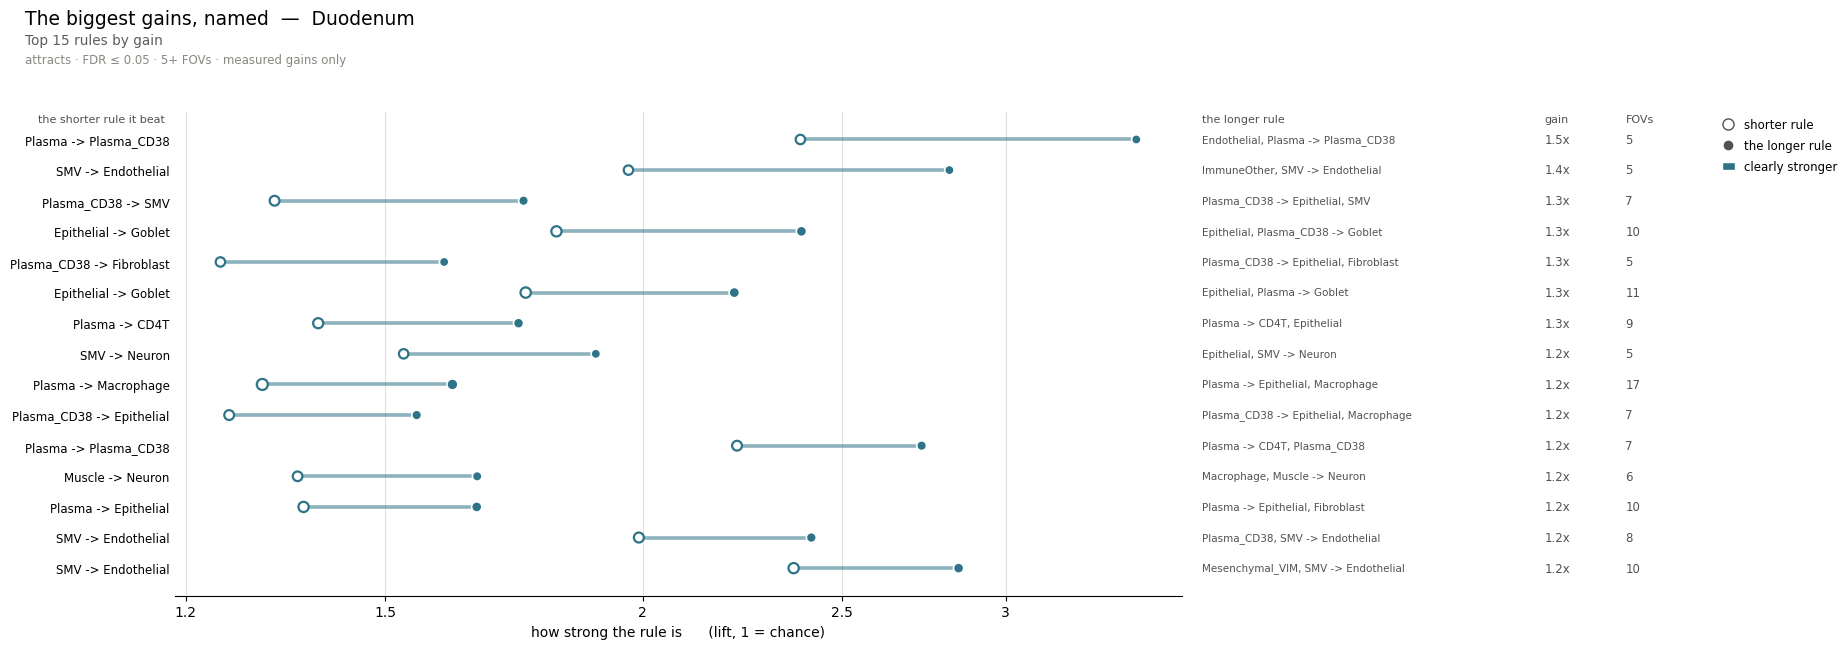

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\gain_attracts_duodenum_with_new.png


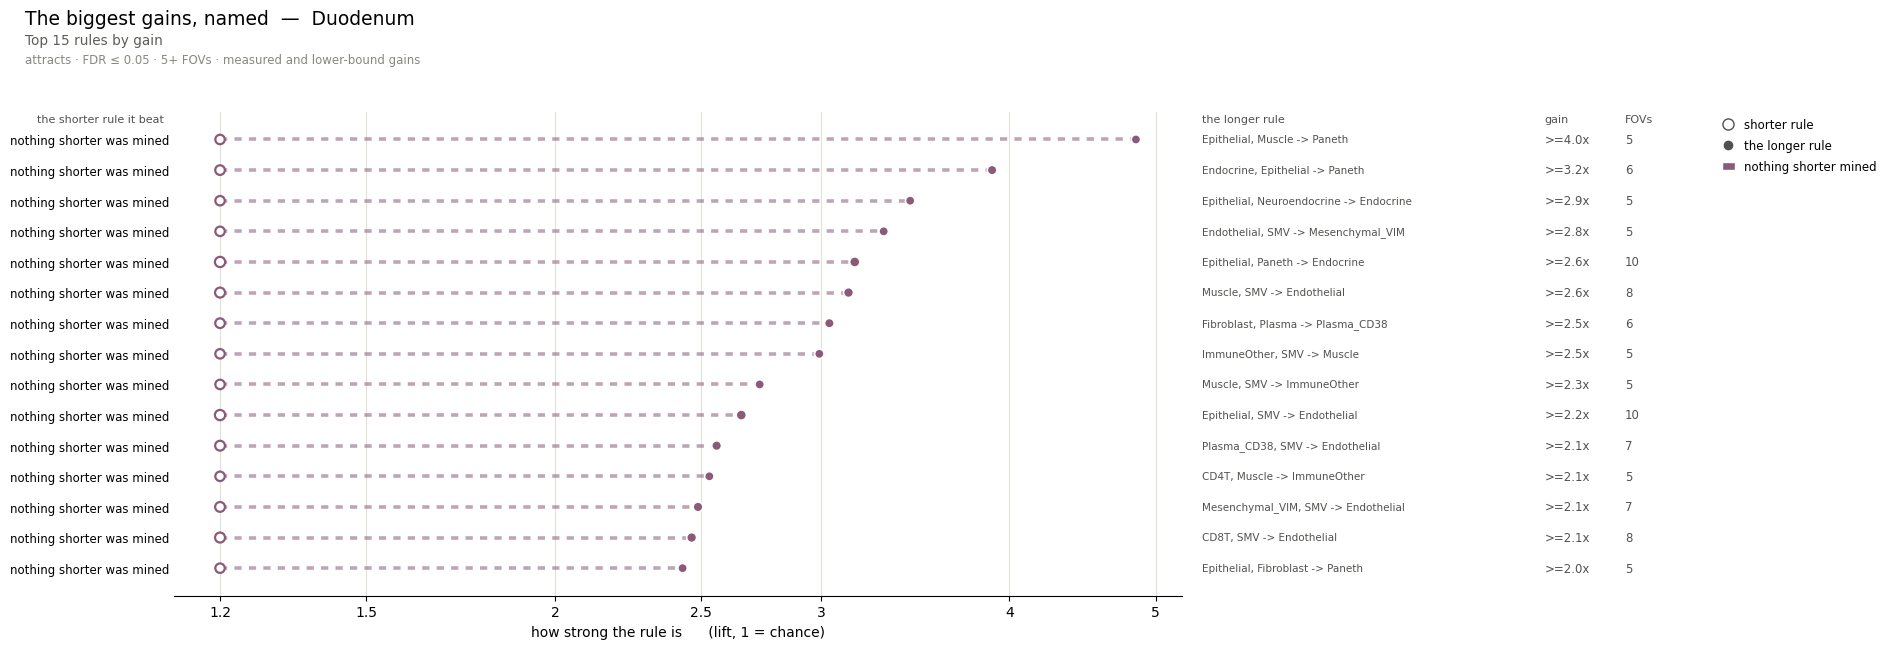

,FOV,rule,detail
0,GVHD_38_FOV_2,"Epithelial, Muscle -> Paneth",Stronger than its best simpler rule · lift gai...
1,GVHD_36_FOV_2,"Epithelial, Plasma -> CD4T",More statistically significant than its best s...


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_duodenum_fov_stronger.png


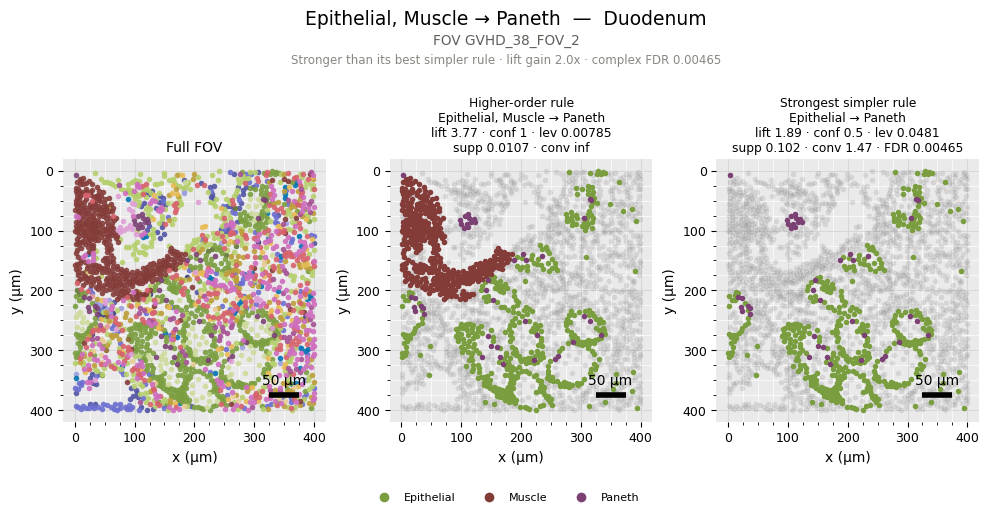

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\attracts_duodenum_fov_significance.png


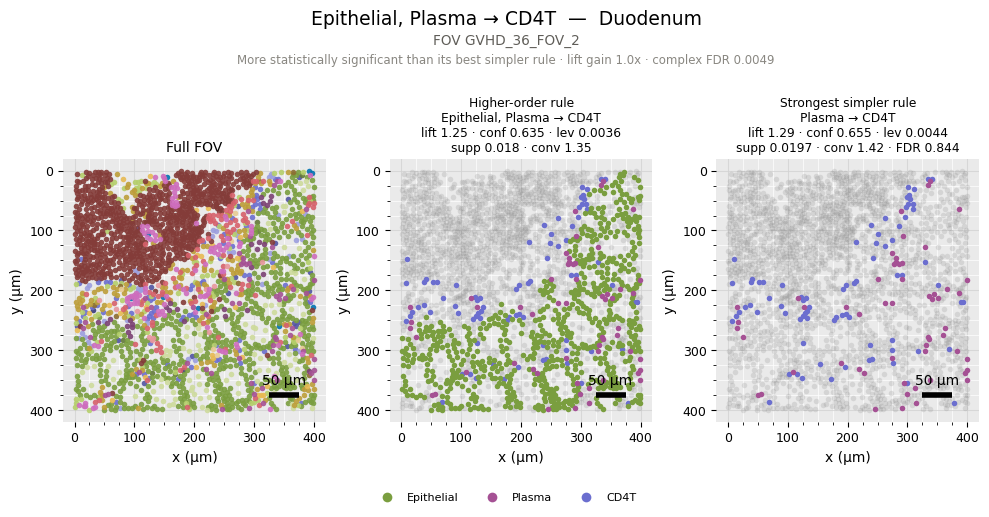

In [13]:
for kind in ["attracts"]:
    display(Markdown(f"#### {kind.title()}"))
    rules = df_results[df_results["Kind"] == kind]
    for organ in ORGAN_ORDER:
        display(Markdown(f"##### {organ}"))
        organ_rules = rules[rules["Organ"] == organ]
        organ_gains = gain_table(organ_rules)
        organ_rows = gain_table(organ_rules, per="fov")
        display(organ_gains.head(TOP_N))
        show_gain_dumbbell(organ_gains, kind, organ=organ,
                           save=f"gain_{kind}_{organ.lower()}_measured.png")
        show_gain_dumbbell(organ_gains, kind, include_new=True, organ=organ,
                           save=f"gain_{kind}_{organ.lower()}_with_new.png")
        show_fov_examples(organ_gains, organ_rows,
                          prefix=f"{kind}_{organ.lower()}")


## Avoidances (negative spatial rules)


### Rule counts

,rules,significant
Rule_Type,,
A -> B,7516,4902
A + B -> C,35069,18754
A -> B + C,31900,15029


### Verdicts

Complex_Class,redundant_by_simpler,consequent_driven,simpler_are_noise,consequent_is_noise,stronger_effect,new
Rule_Type,,,,,,
ant-complex,14037,0,8708,0,7369,4955
con-complex,8617,1302,6078,258,13612,2033


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_avoids_all.png


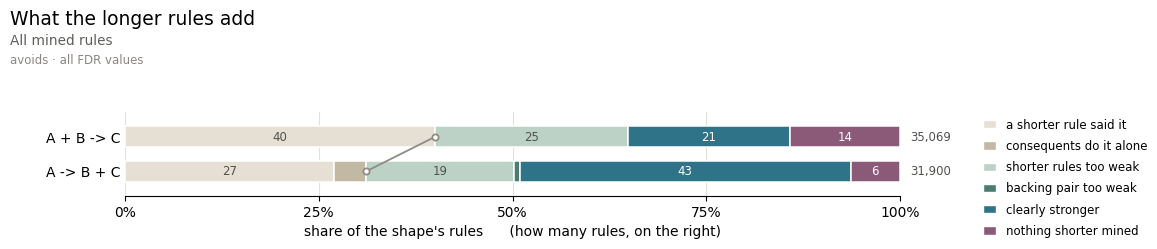

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_avoids_supported.png


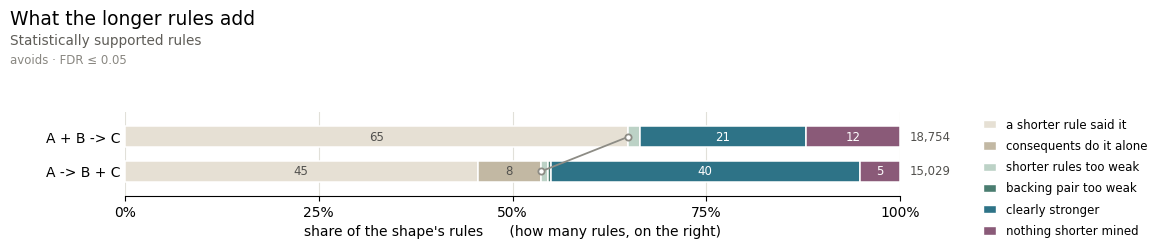

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_avoids_by_stage_path.png


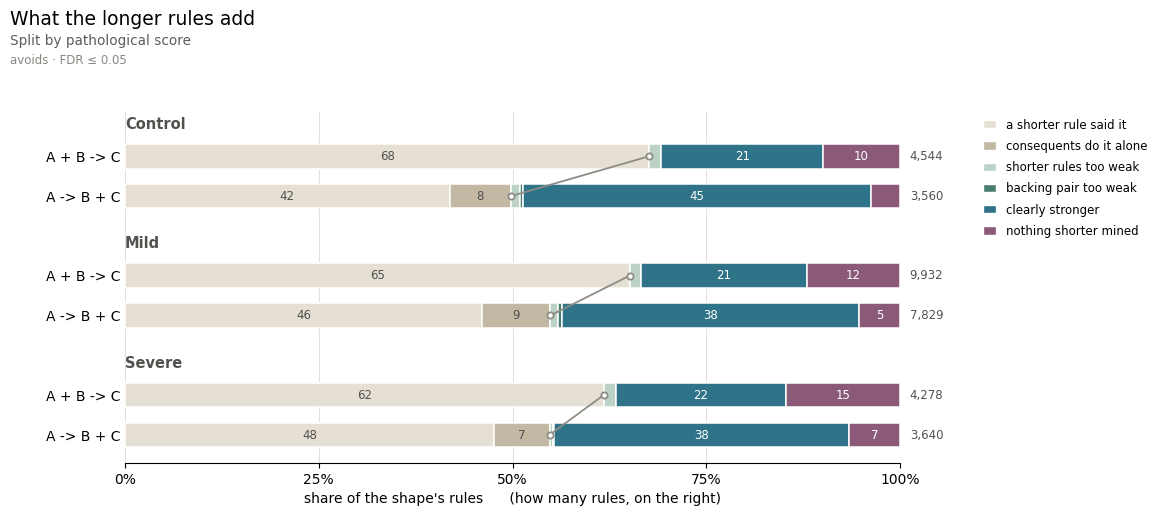

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_avoids_colon.png


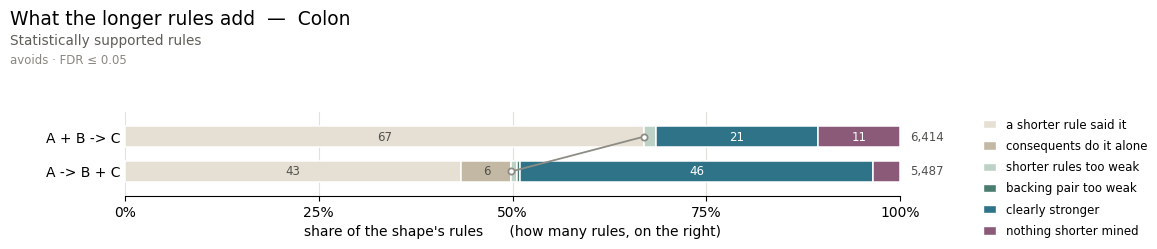

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\verdicts_avoids_duodenum.png


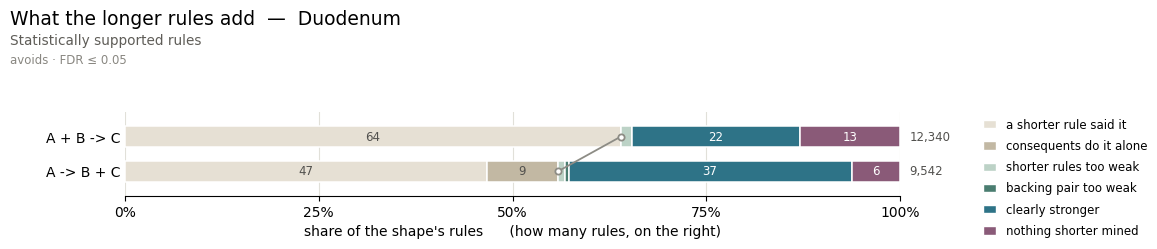

### Strength gains

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
273,"Epithelial, SMV -> Muscle",ant-complex,stronger_effect,1000000.000000,12.985530,14,Epithelial -> Muscle,77008.791879
769,"Muscle -> Epithelial, Plasma",con-complex,stronger_effect,1000000.000000,13.111522,11,Muscle -> Epithelial,76268.798884
865,"Muscle, Neuron -> Goblet",ant-complex,stronger_effect,1000000.000000,14.630191,10,Muscle -> Goblet,68351.805487
254,"Epithelial, Goblet -> Muscle",ant-complex,stronger_effect,1000000.000000,16.060166,43,Epithelial -> Muscle,62265.856494
704,"Muscle -> CD4T, Epithelial",con-complex,stronger_effect,500006.117211,8.658442,6,Muscle -> Epithelial,57747.816632
772,"Muscle -> Epithelial, SMV",con-complex,stronger_effect,500067.051139,10.309258,10,Muscle -> Epithelial,48506.599704
801,"Muscle -> Goblet, Neuron",con-complex,stronger_effect,500008.319774,11.317651,6,Muscle -> Goblet,44179.512780
731,"Muscle -> CD8T, Goblet",con-complex,stronger_effect,1000000.000000,23.634847,11,Muscle -> Goblet,42310.406601
802,"Muscle -> Goblet, Plasma",con-complex,stronger_effect,1000000.000000,23.634847,13,Muscle -> Goblet,42310.406601
272,"Epithelial, Plasma -> Muscle",ant-complex,stronger_effect,1000000.000000,28.629391,21,Epithelial -> Muscle,34929.139655


,FOV,rule,detail
0,Control_Colon_04_FOV_1,"Muscle -> Fibroblast, Monocyte",Stronger than its best simpler rule · lift gai...
1,GVHD_27_FOV_2,"CD3T, Epithelial -> Mesenchymal_VIM",More statistically significant than its best s...


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_fov_stronger.png


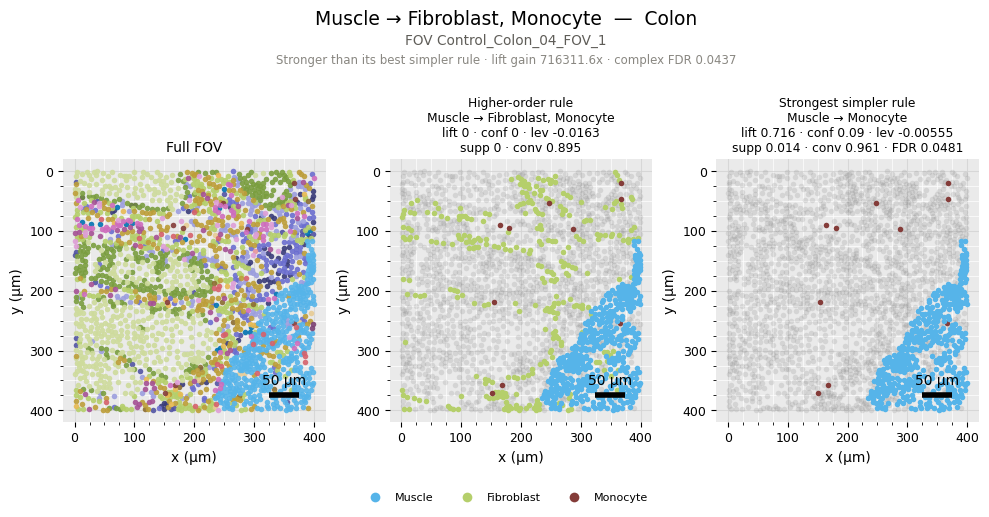

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_fov_significance.png


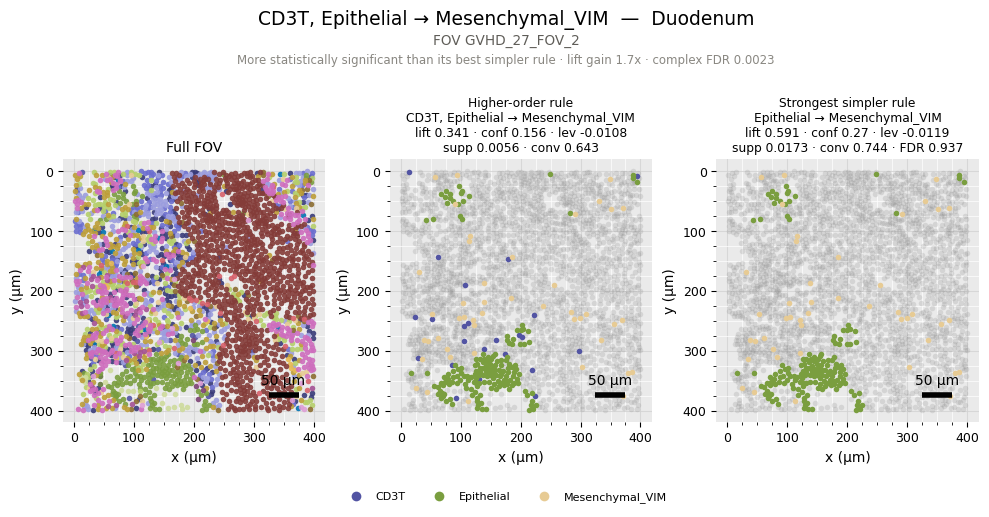

### New complex rules

95 new rules in 5+ FOVs; 11 dropped by median strength < 1.3


,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
69,"Muscle -> Fibroblast, Macrophage",con-complex,new,1.387962,1.25,18,nothing shorter was mined,1.110369
78,"Muscle, SMV -> Fibroblast",ant-complex,new,1.383069,1.25,18,nothing shorter was mined,1.106455
43,"Fibroblast, Neuron -> Goblet",ant-complex,new,1.395958,1.25,15,nothing shorter was mined,1.116766
15,"Endothelial, Fibroblast -> Goblet",ant-complex,new,1.646213,1.25,13,nothing shorter was mined,1.316970
32,"Fibroblast, Mesenchymal_VIM -> Goblet",ant-complex,new,1.639991,1.25,13,nothing shorter was mined,1.311993
19,"Endothelial, SMV -> Epithelial",ant-complex,new,1.400655,1.25,13,nothing shorter was mined,1.120524
79,"Muscle, SMV -> Macrophage",ant-complex,new,1.386114,1.25,13,nothing shorter was mined,1.108891
2,"CD4T, Fibroblast -> Goblet",ant-complex,new,1.323266,1.25,12,nothing shorter was mined,1.058612
63,"Mesenchymal_VIM, Muscle -> Fibroblast",ant-complex,new,1.519350,1.25,11,nothing shorter was mined,1.215480
5,"CD4T, Muscle -> Fibroblast",ant-complex,new,1.370042,1.25,11,nothing shorter was mined,1.096034


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\gain_new_avoids.png


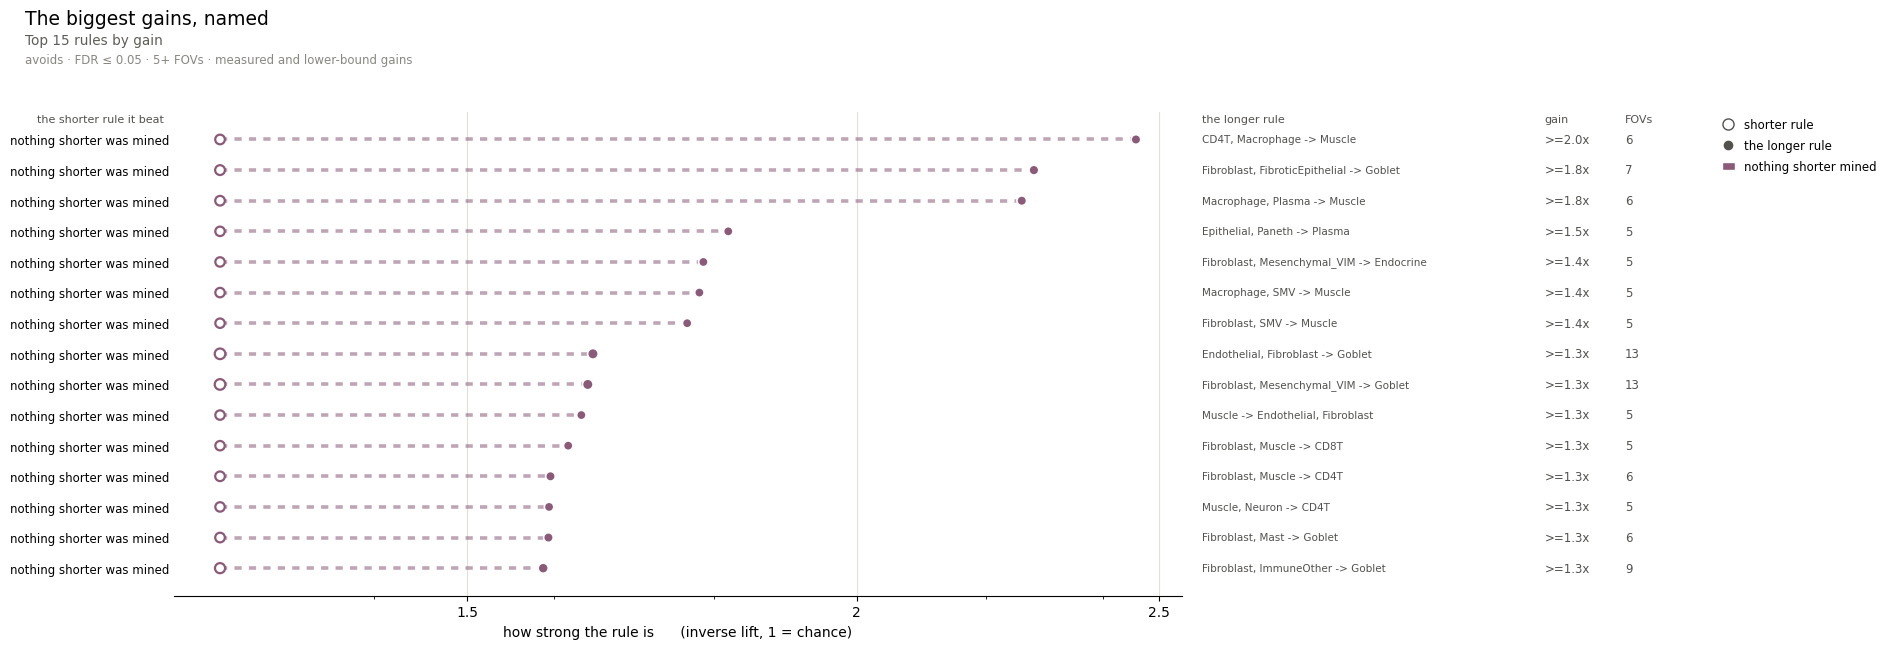

,FOV,rule,detail
0,GVHD_15_FOV_1,"Muscle -> Fibroblast, Macrophage",New rule · effect strength ≥ 1.3 · FDR 0.00656
1,GVHD_50_FOV_1,"Muscle, SMV -> Fibroblast",New rule · effect strength ≥ 1.3 · FDR 0.00254
2,Control_Colon_02_FOV_2,"Fibroblast, Neuron -> Goblet",New rule · effect strength ≥ 1.3 · FDR 0.00321
3,GVHD_37_FOV_1,"Endothelial, Fibroblast -> Goblet",New rule · effect strength ≥ 1.3 · FDR 0.00267


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_newfov_muscle_fibroblast_macrophage.png


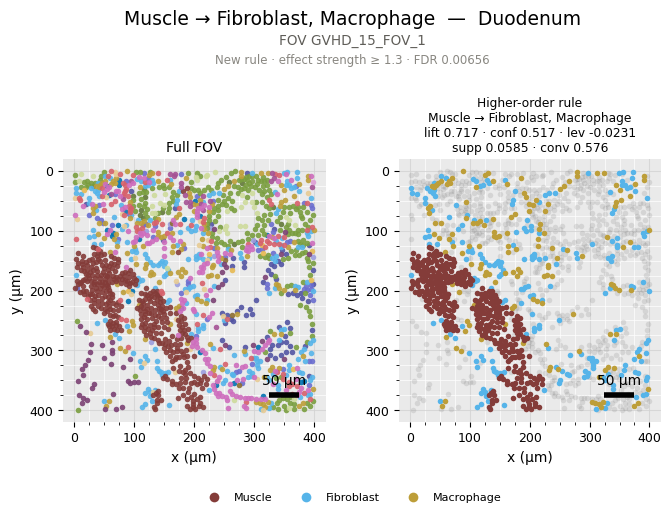

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_newfov_muscle_smv_fibroblast.png


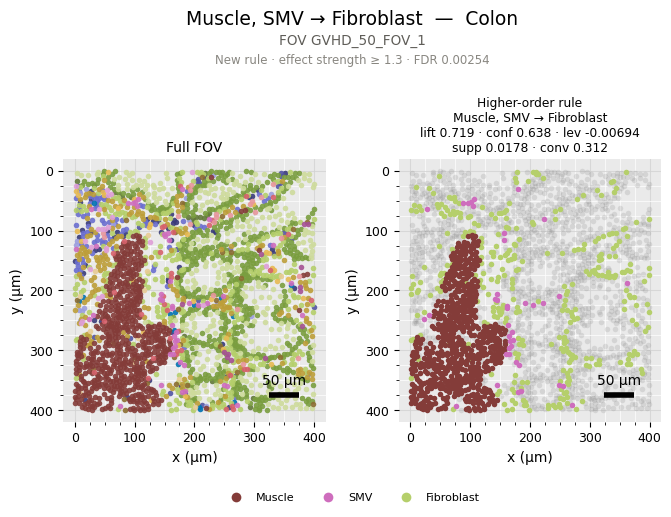

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_newfov_fibroblast_neuron_goblet.png


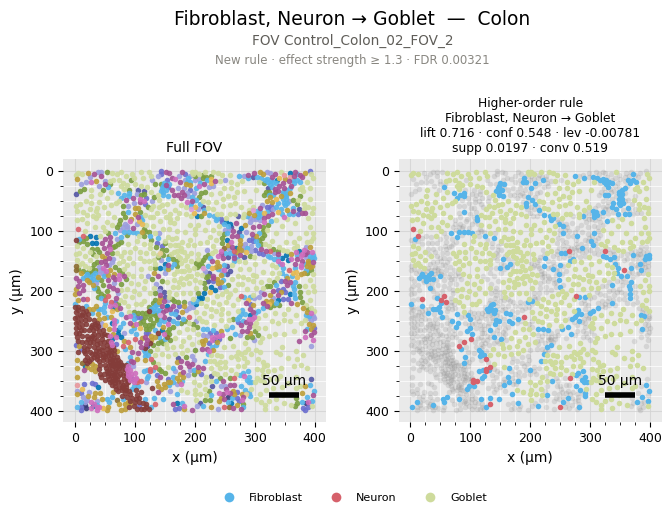

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_newfov_endothelial_fibroblast_goblet.png


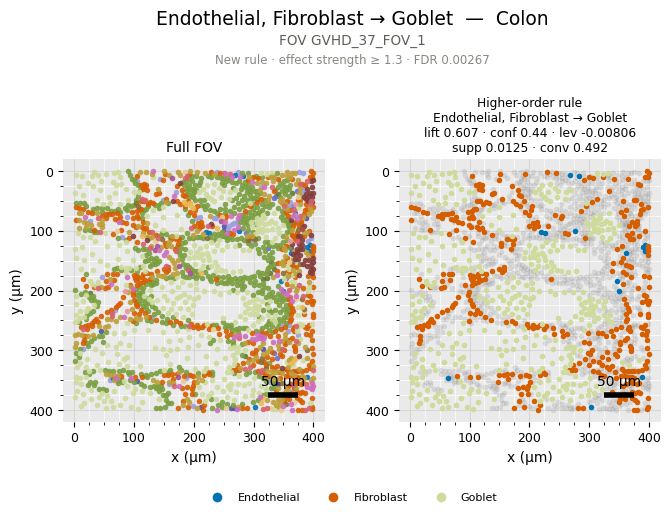

### Colon and duodenum

#### Colon

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
296,"Muscle -> CD4T, Treg",con-complex,stronger_effect,1000000.000000,6.105409,7,Muscle -> Treg,163789.186733
350,"Muscle -> Mast, Plasma",con-complex,stronger_effect,1000000.000000,6.804263,6,Muscle -> Plasma,146966.686053
315,"Muscle -> Endothelial, Plasma",con-complex,stronger_effect,500016.047227,8.530964,6,Muscle -> Plasma,58611.905172
302,"Muscle -> CD8T, Goblet",con-complex,stronger_effect,1000000.000000,20.630149,8,Muscle -> Goblet,48472.747290
321,"Muscle -> Fibroblast, Goblet",con-complex,stronger_effect,1000000.000000,23.634847,5,Muscle -> Goblet,42310.406601
108,"Fibroblast, Muscle -> Goblet",ant-complex,stronger_effect,500012.333728,15.955172,6,Muscle -> Goblet,31338.573806
352,"Muscle -> Plasma, SMV",con-complex,stronger_effect,1000000.000000,34.751128,6,Muscle -> Plasma,28776.044484
50,"CD8T, Muscle -> Goblet",ant-complex,stronger_effect,1000000.000000,36.061081,6,Muscle -> Goblet,27730.726992
370,"Muscle, SMV -> Goblet",ant-complex,stronger_effect,1000000.000000,36.061081,8,Muscle -> Goblet,27730.726992
83,"Epithelial, Plasma -> Muscle",ant-complex,stronger_effect,1000000.000000,38.332153,6,Epithelial -> Muscle,26087.759815


,FOV,rule,detail
0,Control_Colon_04_FOV_1,"Muscle -> Fibroblast, Monocyte",Stronger than its best simpler rule · lift gai...
1,GVHD_59_FOV_1,"Epithelial, Goblet -> Monocyte",More statistically significant than its best s...


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_colon_fov_stronger.png


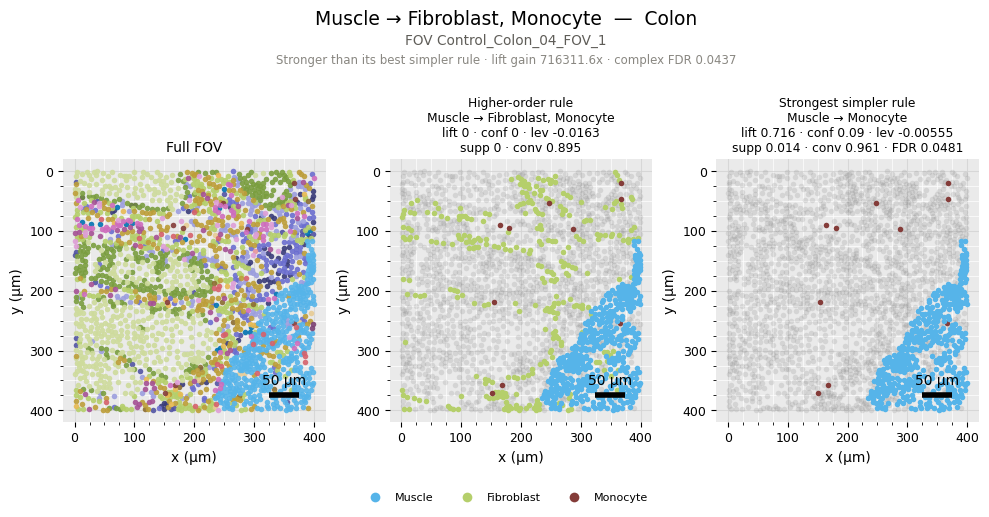

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_colon_fov_significance.png


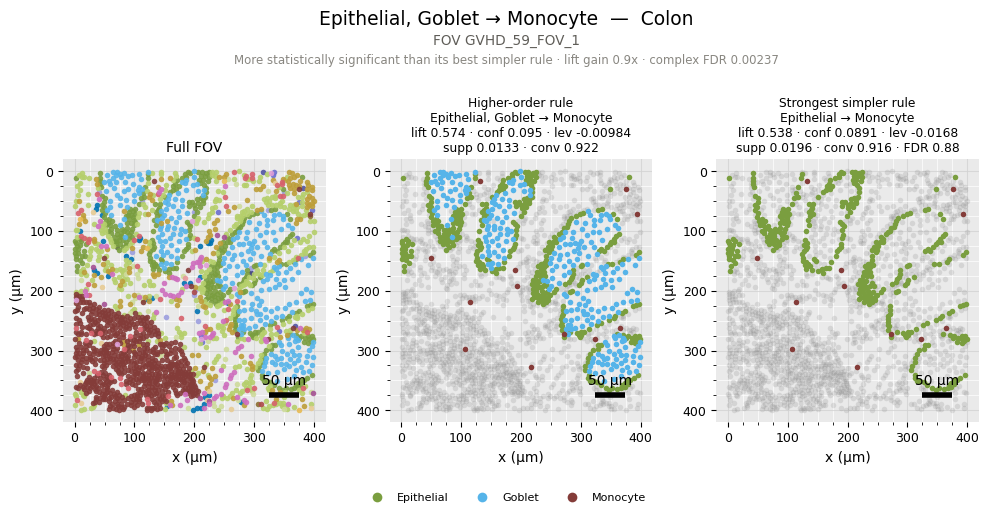

#### Duodenum

,name,Rule_Type,verdict,strength,parent,fovs,parent_name,gain
490,"Muscle -> Epithelial, Plasma",con-complex,stronger_effect,1000000.000000,13.111522,9,Muscle -> Epithelial,76268.798884
157,"Epithelial, Goblet -> Muscle",ant-complex,stronger_effect,1000000.000000,14.204139,34,Epithelial -> Muscle,70402.012555
371,"Macrophage, Muscle -> Goblet",ant-complex,stronger_effect,500017.690339,7.459123,6,Muscle -> Goblet,67034.376383
511,"Muscle -> Goblet, Plasma",con-complex,stronger_effect,1000000.000000,17.620744,6,Muscle -> Goblet,56751.294001
574,"Muscle, SMV -> Goblet",ant-complex,stronger_effect,1000000.000000,17.711701,5,Muscle -> Goblet,56459.850773
170,"Epithelial, Plasma -> Muscle",ant-complex,stronger_effect,1000000.000000,21.183779,15,Epithelial -> Muscle,47205.930270
171,"Epithelial, SMV -> Muscle",ant-complex,stronger_effect,500008.606372,12.985530,12,Epithelial -> Muscle,38505.058706
160,"Epithelial, Macrophage -> Muscle",ant-complex,stronger_effect,1000000.000000,44.649154,8,Epithelial -> Muscle,22396.840718
72,"CD8T, Epithelial -> Muscle",ant-complex,stronger_effect,1000000.000000,85.519188,5,Epithelial -> Muscle,11693.282166
548,"Muscle -> Neuron, Plasma_CD38",con-complex,stronger_effect,19.933857,2.986977,13,Muscle -> Plasma_CD38,6.673588


,FOV,rule,detail
0,GVHD_16_FOV_3,"Muscle, Neuron -> CD4T",Stronger than its best simpler rule · lift gai...
1,GVHD_27_FOV_3,"Endothelial, SMV -> Epithelial",More statistically significant than its best s...


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_duodenum_fov_stronger.png


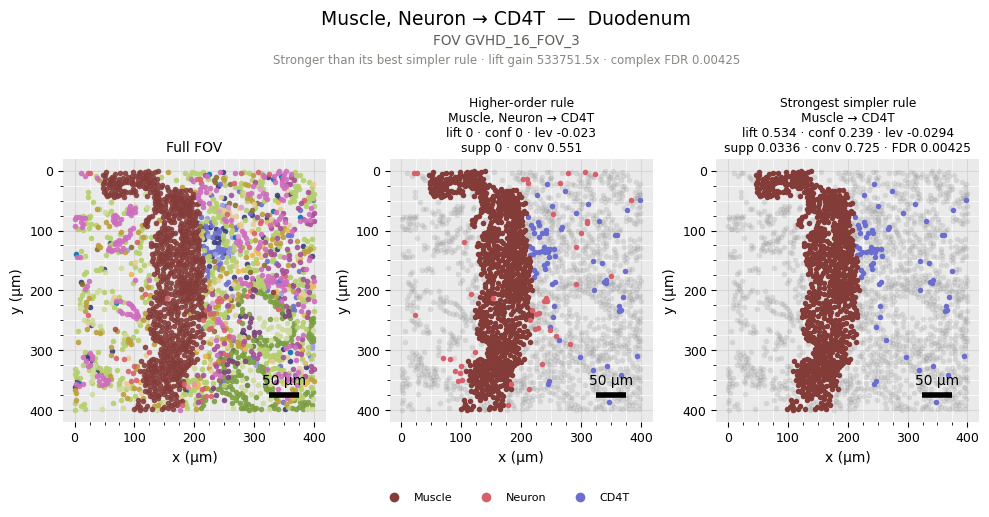

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\avoids_duodenum_fov_significance.png


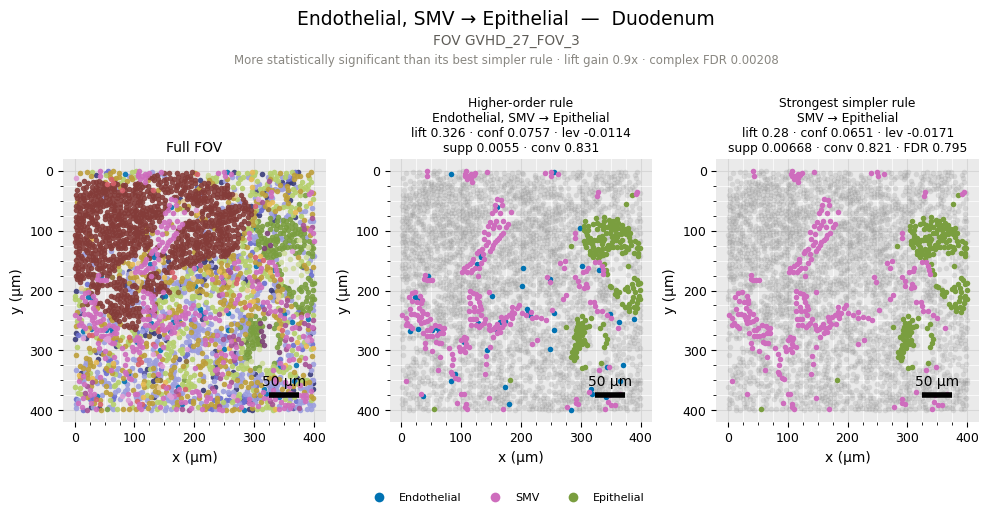

In [14]:
kind = "avoids"
rules = df_results[df_results["Kind"] == kind]

display(Markdown("### Rule counts"))
display(rule_counts(rules))

display(Markdown("### Verdicts"))
display(class_split(rules))
show_class_split(rules, kind, save=f"verdicts_{kind}_all.png")
show_class_split(rules, kind, max_fdr=MAX_FDR,
                 save=f"verdicts_{kind}_supported.png")
show_class_split(rules, kind, split_by=SCORE_COLUMN, max_fdr=MAX_FDR,
                 save=f"verdicts_{kind}_by_stage_{SCORE_TAG}.png")
for organ in ORGAN_ORDER:
    show_class_split(
        rules[rules["Organ"] == organ], kind,
        max_fdr=MAX_FDR, organ=organ,
        save=f"verdicts_{kind}_{organ.lower()}.png",
    )

display(Markdown("### Strength gains"))
# No gain ranking for avoidance: where a rule has lift 0 the gain ratio explodes,
# so the chart would rank arithmetic artefacts. The FOV examples below show the same
# fact honestly - a real pair of cell types that never share a neighbourhood.
gains = gain_table(rules)
gain_rows = gain_table(rules, per="fov")
display(gains.head(TOP_N))
show_fov_examples(gains, gain_rows, prefix=kind)

display(Markdown("### New complex rules"))
new_table, new_rows = new_results(rules)
display(new_table.head(TOP_N))
show_gain_dumbbell(new_table, kind, include_new=True,
                   save=f"gain_new_{kind}.png")
show_new_fov_examples(new_table, new_rows, prefix=kind, n=NEW_FOV_EXAMPLES)

display(Markdown("### Colon and duodenum"))
for organ in ORGAN_ORDER:
    display(Markdown(f"#### {organ}"))
    organ_rules = rules[rules["Organ"] == organ]
    organ_gains = gain_table(organ_rules)
    organ_rows = gain_table(organ_rules, per="fov")
    display(organ_gains.head(TOP_N))
    show_fov_examples(organ_gains, organ_rows,
                      prefix=f"{kind}_{organ.lower()}")
